# 소나무재선충병 피해 예측 — **Fisher-KPP + PINN**  (2016–2023 데이터)

산림청 **병해충발생정보관리** 연도별 자료(`Data/산림청_산림병해충방제_데이터/*.csv`, 2016–2023)를 이용해
**감염목(피해목)의 시·공간 확산을 물리 기반으로 학습하고 미래를 예측**한다.

## 방법론
생물 침입·전염 확산의 표준 모형인 **Fisher–KPP 반응-확산 방정식**을 지배방정식으로 사용한다.

$$\frac{\partial u}{\partial t} \;=\; D\,\nabla^2 u \;+\; r\,u\,(1-u)$$

- $u(x,y,t)$ : 정규화된 감염 밀도 ($0$=청정, $1$=포화/수용능력)
- $D$ : **확산계수** — 매개충(솔수염하늘소)에 의한 공간 확산
- $r$ : **성장률** — 국소 증식, $u(1-u)$ 는 수용능력에 의한 포화

이를 **PINN(Physics-Informed Neural Network)** 으로 풀어, 신경망 $\mathcal{N}(x,y,t)\to u$ 가
(1) **연도별 관측 감염밀도**와 (2) **PDE 잔차**를 동시에 만족하도록 학습하며 $D,\,r$ 를 **역추정**한다.

## 학습/검증/예측 구성
- **학습**: 2016–2022 (조사일자 1~12월 **완전 연도** 7개)
- **검증**: **2023** (1~4월 **부분관측** — 새로 확보한 실제 자료로 공간패턴 검증)
- **예측**: 2024–2026 (물리법칙을 따른 외삽)
- **확산 예측**: ~2030, 소진(burn-out) 고려 공간 SIR (감염→제거 후 재감염 없음)

> 📌 좌표 `지역X/Y좌표` 는 **EPSG:5186**(Korea 2010 중부원점)이며, 지도/작업 좌표계 **EPSG:5179** 로 재투영한다.
> CSV 인코딩은 **CP949**.

## 산출물 (`outputs/*.png`) — 모두 **대한민국 지도 위에 매핑**
| 파일 | 내용 |
|---|---|
| `01_eda_overview.png` | 연도별 발생량 · 공간 분포 |
| `02_observed_density_by_year.png` | 관측 감염밀도 (2016–2023) |
| `03_training_loss.png` | 학습 손실 · 물리 파라미터 수렴 |
| `04_pinn_fit_vs_observed.png` | 관측 vs PINN 재현 |
| `05_validation_2023.png` | **2023 실제(부분) vs PINN 예측 검증** |
| `06_forecast_future.png` | **미래 피해 예측 (2024–2026)** |
| `07_spread_timeline.png` | 확산 타임라인 2016→2026 |
| `08_hotspot_change.png` | 예측 피해 증감 (2026−2022) |
| `09_sir_forecast_2030.png` | **소진 고려 SIR 확산 예측 (~2030)** |
| `10_province_damage.png` | 시도별 피해 순위 |
| `11_damage_trajectory.png` | 피해 추이 곡선 2016→2030 |


In [1]:
import os, glob, time, warnings, ssl, urllib.request, collections
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import geopandas as gpd
from pyproj import Transformer
from shapely import contains as shp_contains, points as shp_points, prepare as shp_prepare

# ── 한글 폰트 ──
for _c in ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]:
    if any(_c == f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _c
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# ── 재현성 / 장치 ──
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cpu")        # PINN 2계 미분 안정성을 위해 CPU 사용

# ── 경로 / 상수 ──
DATA_CSV = "Data/산림청_산림병해충방제_데이터"
OUT, CACHE, ASSETS = "outputs", "cache", "assets"
for d in (OUT, CACHE, ASSETS):
    os.makedirs(d, exist_ok=True)
SRC_CRS = "EPSG:5179"               # 지도/작업 좌표계 (단위 m)
CSV_CRS = "EPSG:5186"               # CSV 지역X/Y좌표 (Korea 2010 중부원점) → 5179 변환
YEARS_TRAIN = [2016, 2017, 2018, 2019, 2020, 2021, 2022]   # 완전 관측연도(학습)
YEAR_VALID  = 2023                  # 부분관측(1~4월) — 검증 참조
YEARS_FCST  = [2024, 2025, 2026]    # 예측
print("torch", torch.__version__, "| device:", DEVICE, "| font:", plt.rcParams["font.family"])

torch 2.8.0 | device: cpu | font: ['AppleGothic']


## 1. 데이터 적재 — 감염목 위치·연도 추출 (+ 캐시)

연도별 CSV(CP949)에서 **감염목구분=='감염목'** 만 골라, 조사일자에서 연도를 얻고
**지역X/Y좌표(EPSG:5186) → EPSG:5179** 로 재투영한다. 결과는 `cache/`에 저장해 재실행을 빠르게 한다.

In [2]:
cache_pts = os.path.join(CACHE, "infected_points_2016_2023.npz")
if os.path.exists(cache_pts):
    _d = np.load(cache_pts)
    PX, PY, PYR = _d["x"], _d["y"], _d["year"]
    print(f"캐시 로드: {len(PX):,} 건")
else:
    files = sorted(glob.glob(os.path.join(DATA_CSV, "*.csv")))
    assert files, "CSV 폴더를 찾을 수 없습니다."
    TR = Transformer.from_crs(CSV_CRS, SRC_CRS, always_xy=True)
    xs, ys, yr_ = [], [], []
    t0 = time.time()
    for f in files:
        d = pd.read_csv(f, encoding="cp949",
                        usecols=["지역X좌표", "지역Y좌표", "감염목구분", "조사일자"])
        d = d[d["감염목구분"] == "감염목"]
        x = pd.to_numeric(d["지역X좌표"], errors="coerce").to_numpy()
        y = pd.to_numeric(d["지역Y좌표"], errors="coerce").to_numpy()
        yr = pd.to_datetime(d["조사일자"], errors="coerce").dt.year.to_numpy()
        m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & np.isfinite(yr)
        gx, gy = TR.transform(x[m], y[m])                  # 5186 → 5179
        xs.append(np.asarray(gx)); ys.append(np.asarray(gy))
        yr_.append(yr[m].astype("int16"))
        print(f"  {os.path.basename(f)} : 감염목 +{int(m.sum()):,}")
    PX = np.concatenate(xs); PY = np.concatenate(ys); PYR = np.concatenate(yr_)
    np.savez_compressed(cache_pts, x=PX, y=PY, year=PYR)
    print(f"감염목 총 {len(PX):,} 건 | {time.time()-t0:.0f}s | 캐시 저장 → {cache_pts}")

print("연도별 감염목:", dict(sorted(collections.Counter(PYR.tolist()).items())))
print("※ 2023년은 1~4월 부분관측(조사 미완) → 학습 제외, 검증 참조용")

캐시 로드: 3,183,376 건


연도별 감염목: {2016: 507503, 2017: 656294, 2018: 486431, 2019: 388949, 2020: 304734, 2021: 298569, 2022: 377380, 2023: 163516}
※ 2023년은 1~4월 부분관측(조사 미완) → 학습 제외, 검증 참조용


## 2. 탐색적 분석 (EDA)

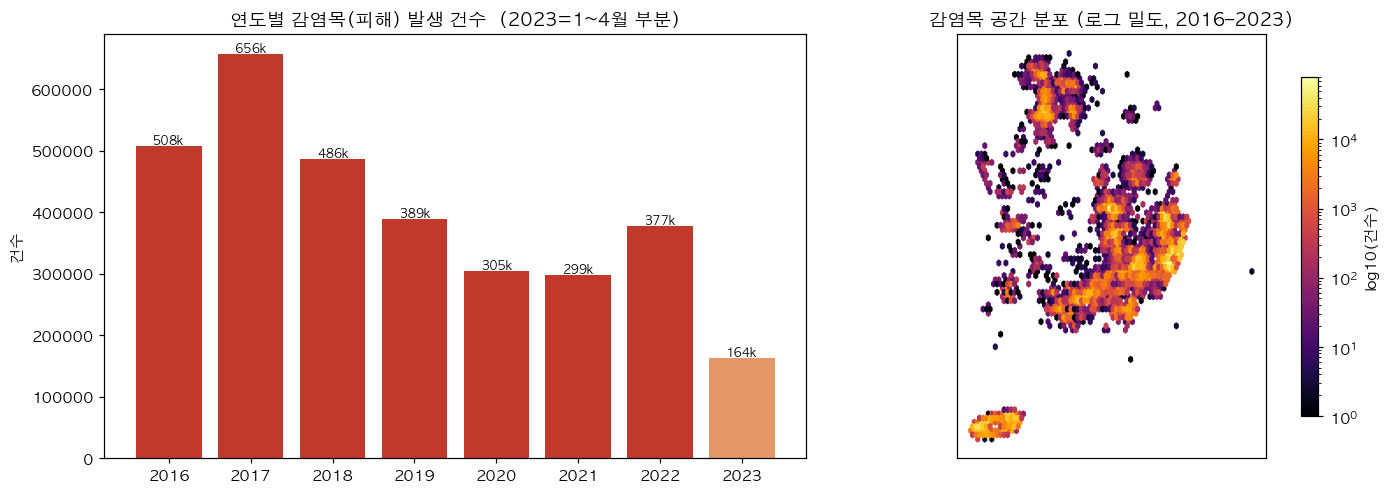

saved → 01_eda_overview.png


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
yrs = sorted(set(PYR.tolist()))
cnts = [int((PYR == y).sum()) for y in yrs]
colors = ["#c0392b" if y != YEAR_VALID else "#e59866" for y in yrs]
ax[0].bar([str(y) for y in yrs], cnts, color=colors)
ax[0].set_title("연도별 감염목(피해) 발생 건수  (2023=1~4월 부분)"); ax[0].set_ylabel("건수")
for i, c in enumerate(cnts):
    ax[0].text(i, c, f"{c/1000:.0f}k", ha="center", va="bottom", fontsize=8)
hb = ax[1].hexbin(PX, PY, gridsize=80, cmap="inferno", bins="log", mincnt=1)
ax[1].set_aspect("equal"); ax[1].set_title("감염목 공간 분포 (로그 밀도, 2016–2023)")
ax[1].set_xticks([]); ax[1].set_yticks([])
fig.colorbar(hb, ax=ax[1], shrink=0.8, label="log10(건수)")
fig.tight_layout()
fig.savefig(f"{OUT}/01_eda_overview.png", dpi=130, bbox_inches="tight")
plt.show(); print("saved → 01_eda_overview.png")

## 3. 대한민국 경계 + 시·공간 밀도 격자 $u_{obs}(x,y,t)$

시도(17개) 경계를 EPSG:5179로 재투영해 지도 배경·육지 마스크로 쓰고, 감염목 분포를 $96\times96$ 격자로 집계한다.
정규화 상수(수용능력)는 **학습연도(2016–2022)** 셀밀도의 99퍼센타일로 고정한다.

In [4]:
geo_path = os.path.join(ASSETS, "skorea_provinces_2018.geojson")
if not os.path.exists(geo_path):
    url = ("https://raw.githubusercontent.com/southkorea/southkorea-maps/"
           "master/kostat/2018/json/skorea-provinces-2018-geo.json")
    ctx = ssl.create_default_context(); ctx.check_hostname = False; ctx.verify_mode = ssl.CERT_NONE
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    open(geo_path, "wb").write(urllib.request.urlopen(req, timeout=40, context=ctx).read())
    print("다운로드:", geo_path)

KOREA = gpd.read_file(geo_path).to_crs(SRC_CRS)
KOREA_PLOT = KOREA.copy()
KOREA_PLOT["geometry"] = KOREA_PLOT.geometry.simplify(1500)  # 표시용 단순화(전국 스케일+속도)
KOREA_UNION = KOREA.geometry.union_all()         # 상세 경계 통합(위상 안정)
shp_prepare(KOREA_UNION)                          # 공간 인덱스 준비 → 점-포함 판정 대폭 가속
def land_mask(xs, ys):                            # 육지 여부 판정 헬퍼(재사용)
    return shp_contains(KOREA_UNION, shp_points(xs, ys))
print("시도 폴리곤:", len(KOREA))

# ── 도메인(감염목 범위 + 여백) & 격자 ──
PAD, GRID_N = 15000.0, 96
xmin, xmax = PX.min() - PAD, PX.max() + PAD
ymin, ymax = PY.min() - PAD, PY.max() + PAD
ex = np.linspace(xmin, xmax, GRID_N + 1)
ey = np.linspace(ymin, ymax, GRID_N + 1)
cx = 0.5 * (ex[:-1] + ex[1:]); cy = 0.5 * (ey[:-1] + ey[1:])
CX, CY = np.meshgrid(cx, cy)                      # (Ny, Nx)

# ── 육지 마스크 ──
LAND = land_mask(CX.ravel(), CY.ravel()).reshape(CX.shape)
print(f"격자 {GRID_N}x{GRID_N} | 육지 셀 {int(LAND.sum())}")

# ── 연도별 밀도 → u ∈ [0,1] ──
def smooth(a):                                   # 가벼운 3x3 분리형 평활(scipy 미사용)
    k = np.array([0.25, 0.5, 0.25])
    b = np.apply_along_axis(lambda v: np.convolve(v, k, mode="same"), 1, a)
    b = np.apply_along_axis(lambda v: np.convolve(v, k, mode="same"), 0, b)
    return b

def year_grid(year):
    m = (PYR == year)
    H, _, _ = np.histogram2d(PX[m], PY[m], bins=[ex, ey])   # (Nx, Ny)
    return smooth(H.T)                                      # (Ny, Nx)

RAW = np.stack([year_grid(y) for y in YEARS_TRAIN])          # (T, Ny, Nx)
CAP = np.percentile(RAW[RAW > 0], 99.0)                      # 수용능력(정규화 상수)
def obs_density(year):
    return np.clip(year_grid(year) / CAP, 0, 1) * LAND
U_OBS = np.clip(RAW / CAP, 0, 1) * LAND[None]                # 학습 관측 (T, Ny, Nx)
print(f"정규화 상수 CAP = {CAP:.1f} (셀당 건수 99퍼센타일) | u_obs 최대 {U_OBS.max():.2f}")

시도 폴리곤: 17
격자 96x96 | 육지 셀 3609


정규화 상수 CAP = 2896.2 (셀당 건수 99퍼센타일) | u_obs 최대 1.00


### 시각화 + 관측 감염밀도 (2016–2023)
2023은 1~4월 부분관측.

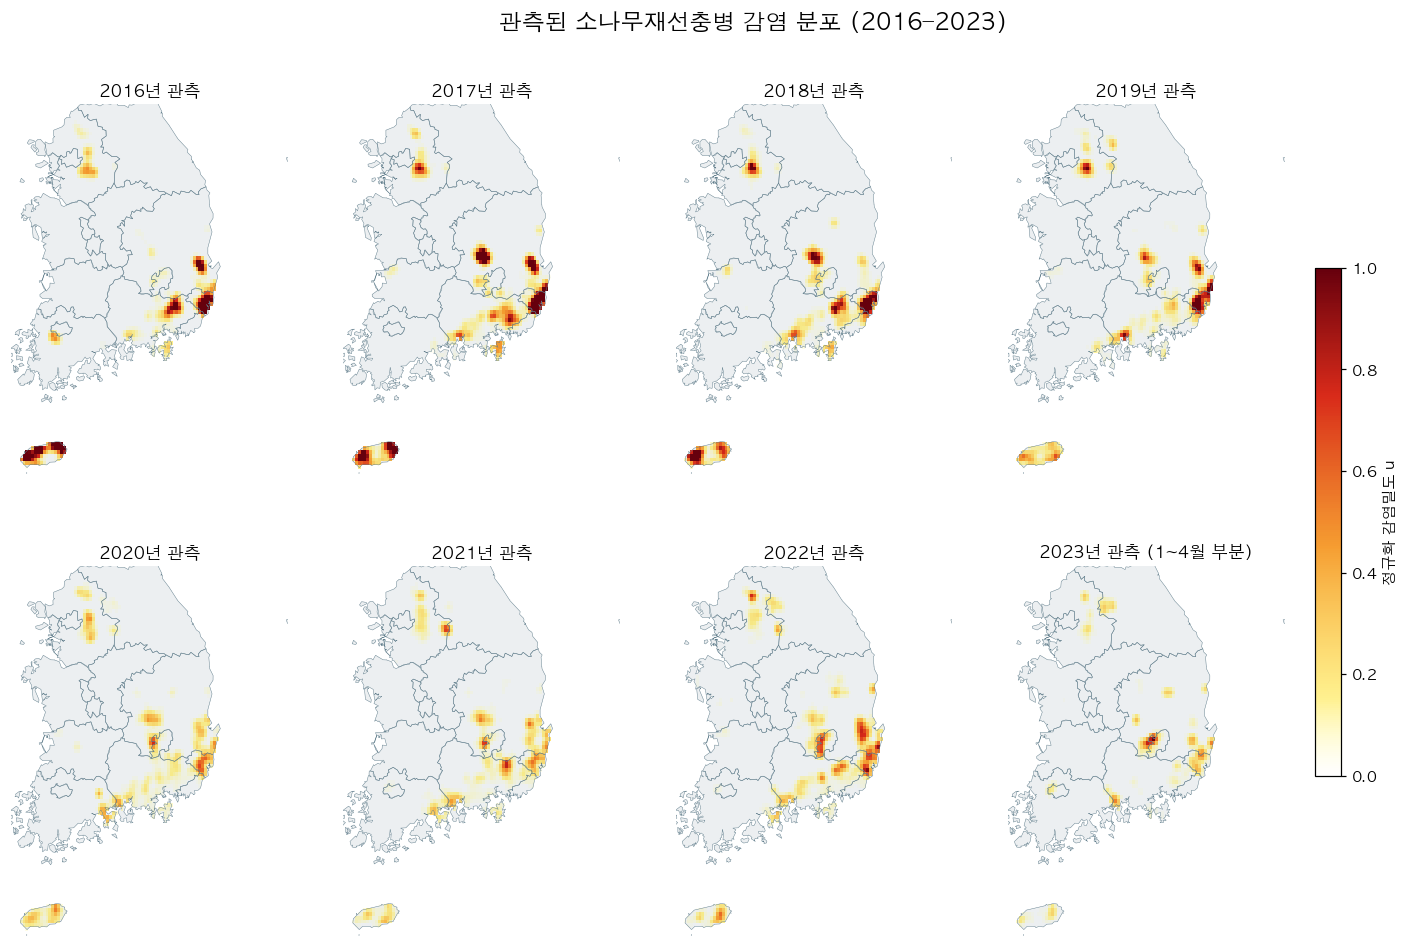

saved → 02_observed_density_by_year.png


In [5]:
# 감염 밀도 전용 컬러맵: 저밀도 투명 → 노랑 → 주황 → 빨강 → 진홍
_stops = [(0.00, (1.00, 1.00, 0.60, 0.00)),
          (0.15, (1.00, 0.90, 0.20, 0.55)),
          (0.45, (0.96, 0.55, 0.05, 0.85)),
          (0.75, (0.84, 0.12, 0.05, 0.95)),
          (1.00, (0.40, 0.00, 0.05, 1.00))]
CMAP = LinearSegmentedColormap.from_list("infect", _stops)

def plot_field(ax, gx, gy, U, title, vmax=1.0, shading="gouraud", thr=0.02):
    """대한민국 지도 위에 감염밀도 U를 매핑."""
    KOREA_PLOT.plot(ax=ax, facecolor="#eceff1", edgecolor="none", zorder=1)
    M = np.ma.masked_where(np.isnan(U) | (U < thr), U)
    pcm = ax.pcolormesh(gx, gy, M, cmap=CMAP, vmin=0, vmax=vmax, shading=shading, zorder=2)
    KOREA_PLOT.boundary.plot(ax=ax, color="#607d8b", linewidth=0.3, zorder=3)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(title, fontsize=11)
    return pcm

yrs_all = YEARS_TRAIN + [YEAR_VALID]            # 2016..2023 (8개)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, yr in zip(axes.ravel(), yrs_all):
    tag = " (1~4월 부분)" if yr == YEAR_VALID else ""
    pcm = plot_field(ax, ex, ey, obs_density(yr), f"{yr}년 관측{tag}", shading="flat")
cb = fig.colorbar(pcm, ax=axes, shrink=0.6, pad=0.02); cb.set_label("정규화 감염밀도 u")
fig.suptitle("관측된 소나무재선충병 감염 분포 (2016–2023)", fontsize=15, y=0.96)
fig.savefig(f"{OUT}/02_observed_density_by_year.png", dpi=125, bbox_inches="tight")
plt.show(); print("saved → 02_observed_density_by_year.png")

## 4. Fisher-KPP PINN 정의

입력 좌표를 등방 스케일 $S$, 시간폭 $\Delta T$ 로 정규화
($X=(x-x_c)/S,\;Y=(y-y_c)/S,\;T=(t-t_0)/\Delta T$). 정규화 좌표의 PDE는

$$u_T = \tilde D\,(u_{XX}+u_{YY}) + \tilde r\,u(1-u),\qquad
\tilde D = D\frac{\Delta T}{S^2},\;\; \tilde r = r\,\Delta T$$

출력은 `sigmoid`로 $u\in[0,1]$, $\tilde D,\tilde r$ 은 `softplus`로 양수 보장되는 학습 파라미터(역추정).
손실 = 데이터 MSE(육지 셀·학습연도) + $w_{pde}$·PDE 잔차 MSE. 콜로케이션 시간은 **예측 지평(2026)까지** 샘플.

In [6]:
# ── 정규화 ──
xc, yc = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
S = 0.5 * max(xmax - xmin, ymax - ymin)            # 등방 길이 스케일 (m)
T0, T1 = YEARS_TRAIN[0], YEARS_TRAIN[-1]; DT = T1 - T0   # 2016~2022 → 6년
nx = lambda x: (x - xc) / S
ny = lambda y: (y - yc) / S
nt = lambda t: (t - T0) / DT

# ── 데이터 텐서(육지 셀 × 학습연도) ──
land_idx = np.where(LAND.ravel())[0]
Xc_n = nx(CX.ravel()[land_idx]); Yc_n = ny(CY.ravel()[land_idx])
dx_l, dy_l, dt_l, du_l = [], [], [], []
for k, yr in enumerate(YEARS_TRAIN):
    dx_l.append(Xc_n); dy_l.append(Yc_n)
    dt_l.append(np.full_like(Xc_n, nt(yr)))
    du_l.append(U_OBS[k].ravel()[land_idx])
to_t = lambda a: torch.tensor(np.concatenate(a), dtype=torch.float32, device=DEVICE).view(-1, 1)
dX, dY, dT, dU = to_t(dx_l), to_t(dy_l), to_t(dt_l), to_t(du_l)
print("데이터 점:", dX.shape[0])

# 콜로케이션 샘플 범위(정규화): 공간=육지 박스, 시간=0~예측지평(2026)
xb = (float(nx(xmin)), float(nx(xmax)))
yb = (float(ny(ymin)), float(ny(ymax)))
tb = (0.0, float(nt(YEARS_FCST[-1])))

class PINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers, d = [], 3
        for _ in range(depth):
            layers.append(nn.Linear(d, width)); d = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(width, 1)
        self.raw_D = nn.Parameter(torch.tensor(-1.0))   # softplus ≈ 0.31
        self.raw_r = nn.Parameter(torch.tensor(-0.5))   # softplus ≈ 0.47
    def forward(self, x, y, t):
        h = torch.cat([x, y, t], 1)
        for lin in self.hidden:
            h = torch.tanh(lin(h))
        return torch.sigmoid(self.out(h))
    @property
    def D(self): return torch.nn.functional.softplus(self.raw_D)
    @property
    def r(self): return torch.nn.functional.softplus(self.raw_r)

def pde_residual(model, x, y, t):
    u = model(x, y, t)
    g = lambda o, i: torch.autograd.grad(o, i, torch.ones_like(o), create_graph=True)[0]
    ux, uy, ut = g(u, x), g(u, y), g(u, t)
    uxx, uyy = g(ux, x), g(uy, y)
    return ut - model.D * (uxx + uyy) - model.r * u * (1.0 - u)

model = PINN().to(DEVICE)
print(model)

데이터 점: 25263
PINN(
  (hidden): ModuleList(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)


## 5. 학습 (데이터 + 물리 손실, 파라미터 역추정)

In [7]:
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2000, gamma=0.5)
N_STEPS, N_COL, N_DAT = 6000, 4096, 4096
# PDE 가중 커리큘럼: 초반 데이터 → 점차 물리 잔차 강화(연도 스냅샷을 동역학으로 연결)
W_MIN, W_MAX, W_RAMP = 0.1, 1.5, 2500
hist = {"total": [], "data": [], "pde": [], "D": [], "r": []}
nD = dX.shape[0]; t0 = time.time()
for step in range(N_STEPS + 1):
    w_pde = W_MIN + (W_MAX - W_MIN) * min(1.0, step / W_RAMP)
    opt.zero_grad()
    di = torch.randint(0, nD, (N_DAT,), device=DEVICE)
    up = model(dX[di], dY[di], dT[di])
    w = 1.0 + 4.0 * dU[di]                       # 감염(고밀도) 셀 가중
    loss_data = (w * (up - dU[di]) ** 2).mean()
    cx_ = torch.empty(N_COL, 1, device=DEVICE).uniform_(*xb).requires_grad_(True)
    cy_ = torch.empty(N_COL, 1, device=DEVICE).uniform_(*yb).requires_grad_(True)
    ct_ = torch.empty(N_COL, 1, device=DEVICE).uniform_(*tb).requires_grad_(True)
    loss_pde = (pde_residual(model, cx_, cy_, ct_) ** 2).mean()
    loss = loss_data + w_pde * loss_pde
    loss.backward(); opt.step(); sched.step()
    if step % 100 == 0:
        hist["total"].append(loss.item()); hist["data"].append(loss_data.item())
        hist["pde"].append(loss_pde.item()); hist["D"].append(model.D.item()); hist["r"].append(model.r.item())
    if step % 1000 == 0:
        print(f"step {step:5d} | w_pde {w_pde:.2f} | total {loss.item():.3e} | data {loss_data.item():.3e} | "
              f"pde {loss_pde.item():.3e} | D {model.D.item():.3f} r {model.r.item():.3f}")
print(f"학습 완료: {time.time()-t0:.0f}s")

# ── 물리 단위 환산 ──
S_km = S / 1000.0
D_phys = model.D.item() * (S_km ** 2) / DT       # km^2 / 년
r_phys = model.r.item() / DT                     # 1 / 년
speed = 2.0 * np.sqrt(max(D_phys * r_phys, 0.0)) # Fisher 파면 전파속도 ~ 2√(Dr)
print(f"\n▶ 학습된 확산계수 D ≈ {D_phys:.1f} km²/년")
print(f"▶ 학습된 성장률   r ≈ {r_phys:.3f} /년")
print(f"▶ 확산 전파속도(근사) 2√(Dr) ≈ {speed:.1f} km/년")

step     0 | w_pde 0.10 | total 2.521e-01 | data 2.509e-01 | pde 1.173e-02 | D 0.314 r 0.473


step  1000 | w_pde 0.66 | total 3.094e-02 | data 2.998e-02 | pde 1.456e-03 | D 0.051 r 0.167


step  2000 | w_pde 1.22 | total 3.129e-02 | data 3.027e-02 | pde 8.398e-04 | D 0.020 r 0.091


step  3000 | w_pde 1.50 | total 2.479e-02 | data 2.372e-02 | pde 7.138e-04 | D 0.009 r 0.065


step  4000 | w_pde 1.50 | total 1.808e-02 | data 1.603e-02 | pde 1.365e-03 | D 0.003 r 0.047


step  5000 | w_pde 1.50 | total 1.702e-02 | data 1.598e-02 | pde 6.907e-04 | D 0.002 r 0.040


step  6000 | w_pde 1.50 | total 1.520e-02 | data 1.375e-02 | pde 9.671e-04 | D 0.001 r 0.033
학습 완료: 98s

▶ 학습된 확산계수 D ≈ 15.5 km²/년
▶ 학습된 성장률   r ≈ 0.005 /년
▶ 확산 전파속도(근사) 2√(Dr) ≈ 0.6 km/년


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


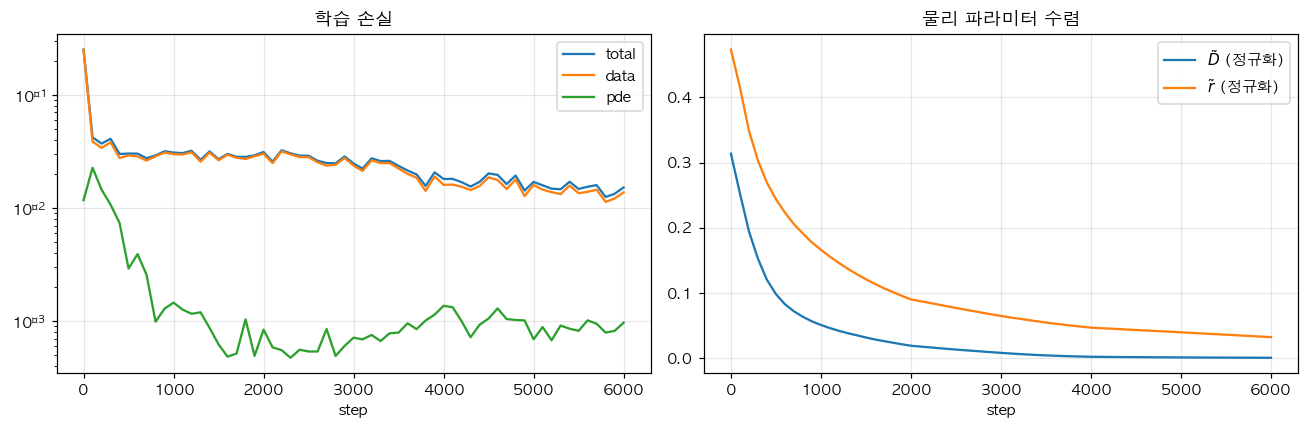

saved → 03_training_loss.png


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
xs = np.arange(len(hist["total"])) * 100
ax[0].semilogy(xs, hist["total"], label="total")
ax[0].semilogy(xs, hist["data"], label="data")
ax[0].semilogy(xs, hist["pde"], label="pde")
ax[0].legend(); ax[0].set_title("학습 손실"); ax[0].set_xlabel("step"); ax[0].grid(alpha=0.3)
ax[1].plot(xs, hist["D"], label=r"$\tilde D$ (정규화)")
ax[1].plot(xs, hist["r"], label=r"$\tilde r$ (정규화)")
ax[1].legend(); ax[1].set_title("물리 파라미터 수렴"); ax[1].set_xlabel("step"); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT}/03_training_loss.png", dpi=130, bbox_inches="tight")
plt.show(); print("saved → 03_training_loss.png")

## 6. 예측 · 검증
고해상도(160×160) 격자에서 신경망을 평가한다. 2016–2022는 *재현*, **2023은 검증**, 2024–2026은 *예측*.

In [9]:
PRED_N = 160
pgx = np.linspace(xmin, xmax, PRED_N); pgy = np.linspace(ymin, ymax, PRED_N)
PGX, PGY = np.meshgrid(pgx, pgy)
PLAND = land_mask(PGX.ravel(), PGY.ravel()).reshape(PGX.shape)
pXt = torch.tensor(nx(PGX.ravel()), dtype=torch.float32, device=DEVICE).view(-1, 1)
pYt = torch.tensor(ny(PGY.ravel()), dtype=torch.float32, device=DEVICE).view(-1, 1)

@torch.no_grad()
def predict_year(year):
    tt = torch.full_like(pXt, float(nt(year)))
    u = model(pXt, pYt, tt).cpu().numpy().reshape(PGX.shape)
    return np.where(PLAND, u, np.nan)

def model_on_coarse(year):                       # 96격자 육지셀 예측값
    xx = torch.tensor(nx(CX.ravel()[land_idx]), dtype=torch.float32).view(-1, 1)
    yy = torch.tensor(ny(CY.ravel()[land_idx]), dtype=torch.float32).view(-1, 1)
    tt = torch.full_like(xx, float(nt(year)))
    with torch.no_grad():
        return model(xx, yy, tt).numpy().ravel()

# 학습연도 적합도
print("[학습연도 적합도]  연도   RMSE     공간상관")
for k, y in enumerate(YEARS_TRAIN):
    up = model_on_coarse(y); uo = U_OBS[k].ravel()[land_idx]
    print(f"               {y}   {np.sqrt(np.mean((up-uo)**2)):.4f}    {np.corrcoef(up, uo)[0,1]:.3f}")

# 2023 검증 (부분관측 대비 — 공간패턴 중심)
uo23 = obs_density(YEAR_VALID).ravel()[land_idx]
up23 = model_on_coarse(YEAR_VALID)
CORR23 = np.corrcoef(up23, uo23)[0, 1]
print(f"\n[2023 검증]  공간상관 r = {CORR23:.3f}  (실제는 1~4월 부분관측이라 절대수준이 아닌 공간패턴 비교)")

[학습연도 적합도]  연도   RMSE     공간상관
               2016   0.0774    0.868
               2017   0.0834    0.867
               2018   0.0797    0.831
               2019   0.0713    0.806
               2020   0.0650    0.768
               2021   0.0681    0.699
               2022   0.0723    0.709

[2023 검증]  공간상관 r = 0.472  (실제는 1~4월 부분관측이라 절대수준이 아닌 공간패턴 비교)


## 7. 결과 시각화 — 대한민국 지도 매핑

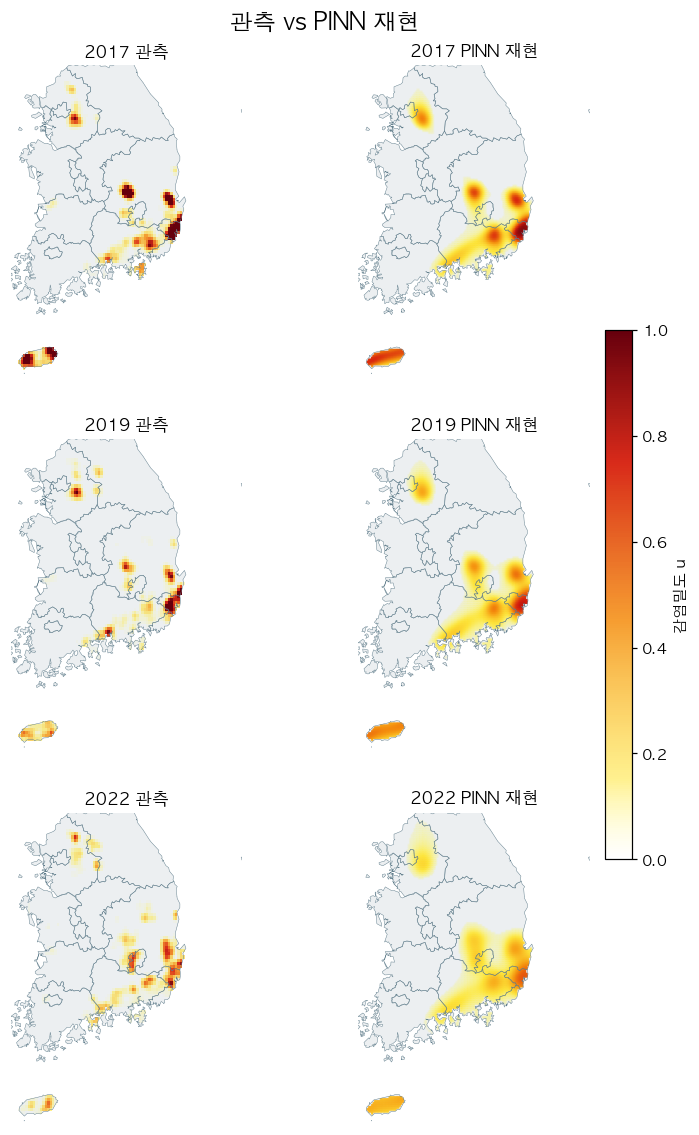

saved → 04_pinn_fit_vs_observed.png


In [10]:
sel = [2017, 2019, 2022]
fig, axes = plt.subplots(len(sel), 2, figsize=(9, 12.5))
for i, yr in enumerate(sel):
    plot_field(axes[i, 0], ex, ey, obs_density(yr), f"{yr} 관측", shading="flat")
    pcm = plot_field(axes[i, 1], pgx, pgy, predict_year(yr), f"{yr} PINN 재현", shading="gouraud")
fig.colorbar(pcm, ax=axes, shrink=0.5, pad=0.02, label="감염밀도 u")
fig.suptitle("관측 vs PINN 재현", fontsize=15, y=0.92)
fig.savefig(f"{OUT}/04_pinn_fit_vs_observed.png", dpi=130, bbox_inches="tight")
plt.show(); print("saved → 04_pinn_fit_vs_observed.png")

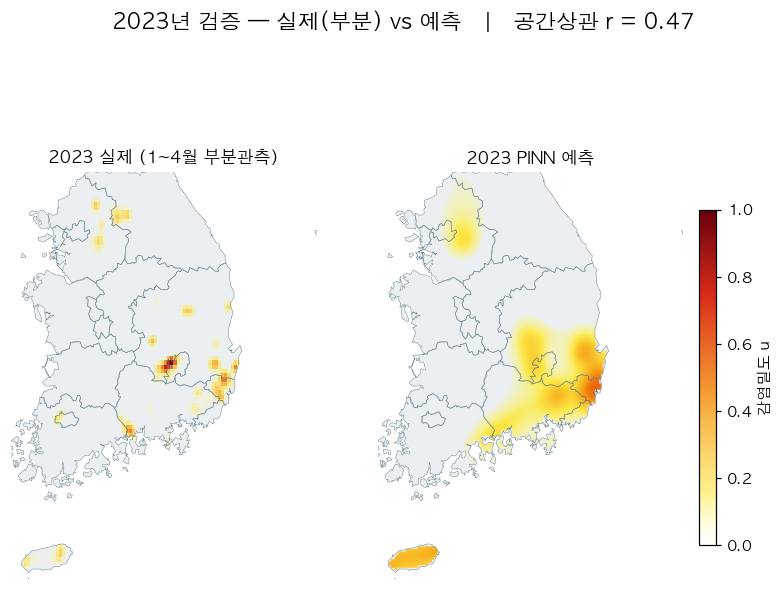

saved → 05_validation_2023.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 6.6))
plot_field(axes[0], ex, ey, obs_density(YEAR_VALID), "2023 실제 (1~4월 부분관측)", shading="flat")
pcm = plot_field(axes[1], pgx, pgy, predict_year(YEAR_VALID), "2023 PINN 예측", shading="gouraud")
fig.colorbar(pcm, ax=axes, shrink=0.6, pad=0.02, label="감염밀도 u")
fig.suptitle(f"2023년 검증 — 실제(부분) vs 예측   |   공간상관 r = {CORR23:.2f}", fontsize=14, y=1.0)
fig.savefig(f"{OUT}/05_validation_2023.png", dpi=140, bbox_inches="tight")
plt.show(); print("saved → 05_validation_2023.png")

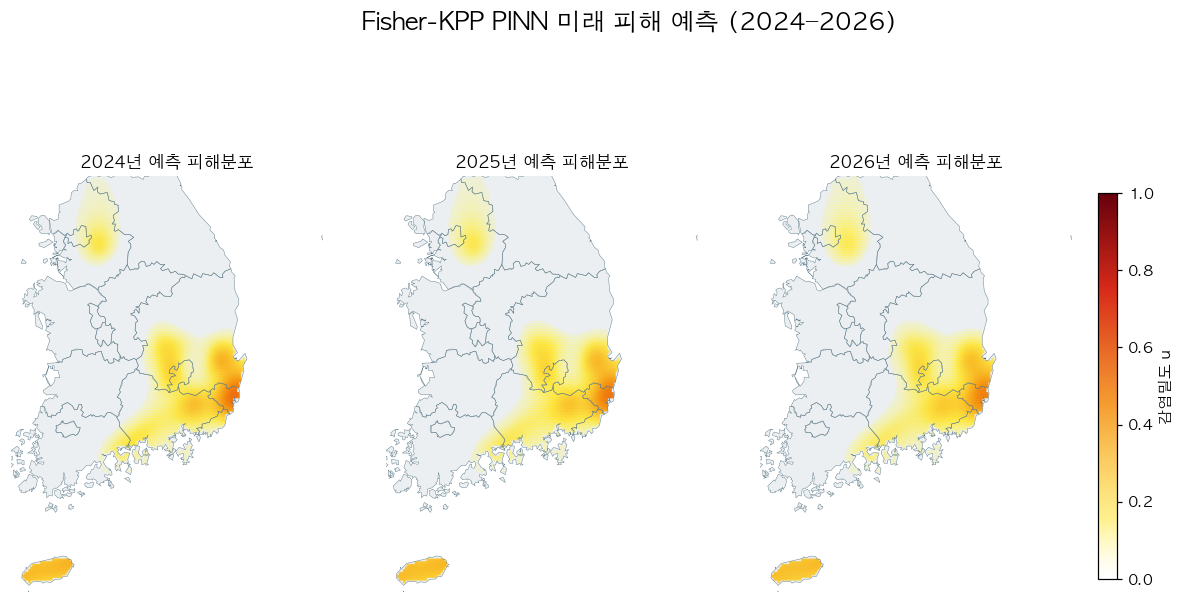

saved → 06_forecast_future.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
for ax, yr in zip(axes, YEARS_FCST):
    pcm = plot_field(ax, pgx, pgy, predict_year(yr), f"{yr}년 예측 피해분포", shading="gouraud")
fig.colorbar(pcm, ax=axes, shrink=0.7, pad=0.02, label="감염밀도 u")
fig.suptitle("Fisher-KPP PINN 미래 피해 예측 (2024–2026)", fontsize=16, y=1.02)
fig.savefig(f"{OUT}/06_forecast_future.png", dpi=140, bbox_inches="tight")
plt.show(); print("saved → 06_forecast_future.png")

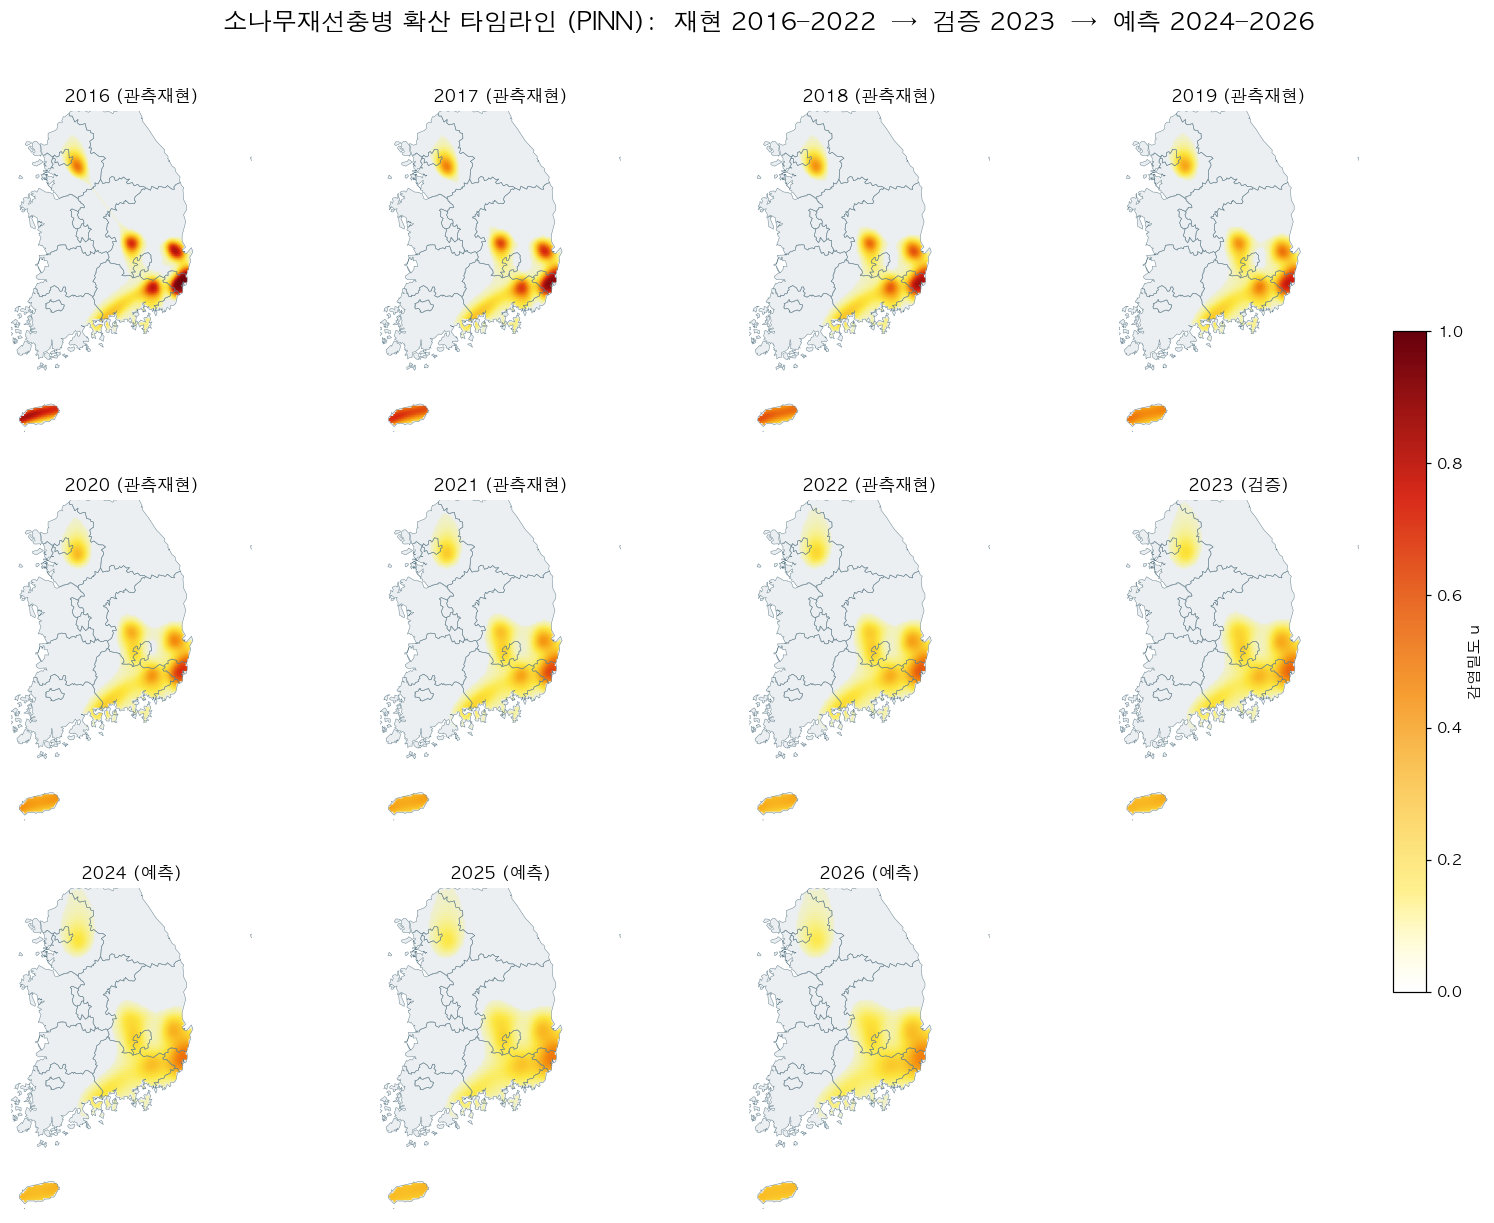

saved → 07_spread_timeline.png


In [13]:
allyears = list(range(2016, 2027))           # 2016..2026 (11개)
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axx = axes.ravel()
for ax, yr in zip(axx, allyears):
    kind = "관측재현" if yr <= 2022 else ("검증" if yr == 2023 else "예측")
    pcm = plot_field(ax, pgx, pgy, predict_year(yr), f"{yr} ({kind})", shading="gouraud")
axx[11].axis("off")                              # 12번째 칸 비움
fig.colorbar(pcm, ax=axes, shrink=0.6, pad=0.02, label="감염밀도 u")
fig.suptitle("소나무재선충병 확산 타임라인 (PINN):  재현 2016–2022  →  검증 2023  →  예측 2024–2026",
             fontsize=16, y=0.95)
fig.savefig(f"{OUT}/07_spread_timeline.png", dpi=120, bbox_inches="tight")
plt.show(); print("saved → 07_spread_timeline.png")

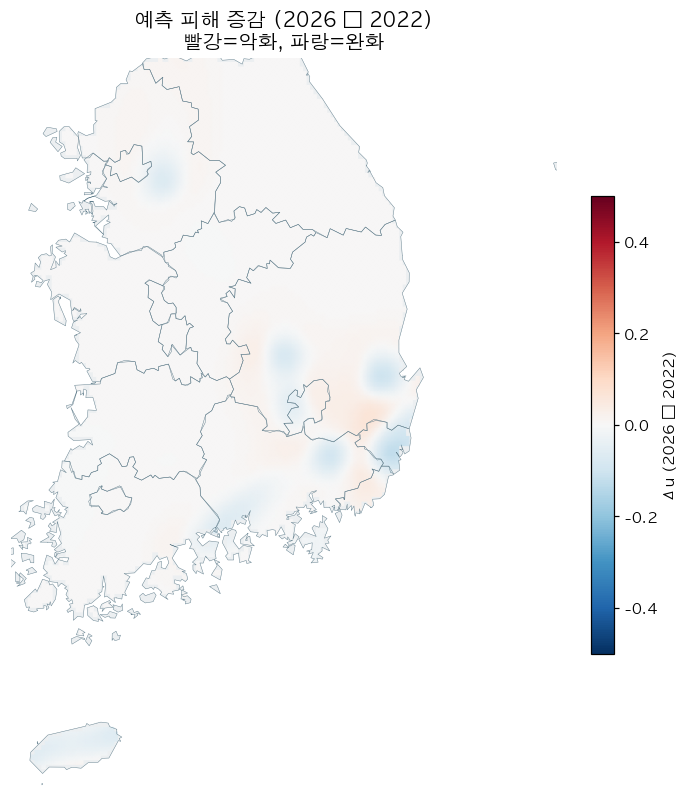

saved → 08_hotspot_change.png


In [14]:
diff = predict_year(2026) - predict_year(2022)
fig, ax = plt.subplots(figsize=(8, 9))
KOREA_PLOT.plot(ax=ax, facecolor="#eceff1", edgecolor="none", zorder=1)
M = np.ma.masked_invalid(diff)
pcm = ax.pcolormesh(pgx, pgy, M, cmap="RdBu_r", vmin=-0.5, vmax=0.5, shading="gouraud", zorder=2)
KOREA_PLOT.boundary.plot(ax=ax, color="#607d8b", linewidth=0.3, zorder=3)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(pcm, ax=ax, shrink=0.6, label="Δu (2026 − 2022)")
ax.set_title("예측 피해 증감 (2026 − 2022)\n빨강=악화, 파랑=완화", fontsize=13)
fig.savefig(f"{OUT}/08_hotspot_change.png", dpi=140, bbox_inches="tight")
plt.show(); print("saved → 08_hotspot_change.png")

## 8. 확산 예측 (~2030) — 소진(burn-out) 고려 공간 SIR

기본 Fisher-KPP는 감염지가 포화 후 **계속 감염 상태로 남는다**고 본다. 그러나 실제 소나무재선충병은
감염목이 고사·제거되면 그 자리의 **감수성 기주(소나무)가 사라져 같은 곳이 다시 감염되지 않고**,
감염 전선이 인접 미감염지로 **이동(소진형 전파)** 한다. 이를 반영해 공간 **SIR** 모형으로 확장한다.

$$\frac{\partial I}{\partial t}=D\nabla^2 I+\beta S I-\gamma I,\qquad
\frac{\partial S}{\partial t}=-\beta S I,\qquad
\frac{\partial R}{\partial t}=\gamma I$$

- $I$ 활성 감염, $S$ 감수성 기주(잔여), $R$ 제거(고사·방제). 한 번 감염→제거된 곳은 $S\!\to\!0$ 이라 **재감염 없음**.
- $D$ 는 PINN이 학습한 확산계수, $\beta,\gamma$ 는 가정값(평균 감염기간 ~2년, $R_0=\beta S/\gamma\approx2$).
- 초기조건: 2022년 관측을 $I_0$, 과거(2016–2022) 발생 범위를 감수성 기주 분포로. **예측 지평은 2030년**(장기 외삽 대신 단기).

In [15]:
# ── 소진(burn-out) 고려 공간 SIR 수치적분 ──
dx_km = (ex[1] - ex[0]) / 1000.0
dy_km = (ey[1] - ey[0]) / 1000.0

def lap_masked(u):
    """육지 한정 라플라시안 (해안 = 무흐름 경계)."""
    lap = np.zeros_like(u)
    for di, dj, h in [(-1, 0, dy_km), (1, 0, dy_km), (0, -1, dx_km), (0, 1, dx_km)]:
        ur = np.roll(u, (di, dj), axis=(0, 1)); lr = np.roll(LAND, (di, dj), axis=(0, 1))
        lap += (np.where(lr, ur, u) - u) / h ** 2
    return lap * LAND

# 감수성 기주(소나무) 분포: 과거(2016~2022) 발생범위를 확장(dilation)해 근사
_foot = np.max([obs_density(y) for y in YEARS_TRAIN], axis=0)
for _ in range(3): _foot = smooth(_foot)
HOST = np.clip(_foot / (np.percentile(_foot[_foot > 0], 50) + 1e-9), 0, 1) * LAND
BETA, GAMMA = 1.2, 0.5             # 전파율, 제거율(가정): 평균 감염기간 ~2년, R0=βS/γ≈2.4

def run_sir(D, beta, gamma, snapshots, dt=0.1):
    I = obs_density(2022).copy() * LAND          # 활성 감염 초기값
    S = np.clip(HOST - I, 0, 1) * LAND           # 잔여 감수성 기주
    cur, outI, outA = 2022, {}, {}
    for y in snapshots:
        for _ in range(int(round((y - cur) / dt))):
            ni = beta * S * I                    # 신규 감염
            I = np.clip(I + dt * (D * lap_masked(I) + ni - gamma * I), 0, 1) * LAND
            S = np.clip(S - dt * ni, 0, 1) * LAND
        outI[y] = I.copy()                       # 활성 감염
        outA[y] = np.clip(HOST - S, 0, 1) * LAND # 누적 피해(소진 포함)
        cur = y
    return outI, outA

SIR_SNAP = list(range(2022, 2031))
sir_I, sir_A = run_sir(D_phys, BETA, GAMMA, SIR_SNAP)
print(f"공간 SIR: D={D_phys:.1f} km²/년, β={BETA}, γ={GAMMA}/년 (R0≈{BETA/GAMMA:.1f}), 2022→2030, dt=0.1")
for y in [2024, 2027, 2030]:
    ai = np.nanmean(np.where(LAND, sir_I[y], np.nan)); ac = np.nanmean(np.where(LAND, sir_A[y], np.nan))
    print(f"  {y}: 활성감염 평균 {ai:.3f} | 누적피해 평균 {ac:.3f}")

공간 SIR: D=15.5 km²/년, β=1.2, γ=0.5/년 (R0≈2.4), 2022→2030, dt=0.1
  2024: 활성감염 평균 0.058 | 누적피해 평균 0.103
  2027: 활성감염 평균 0.088 | 누적피해 평균 0.245
  2030: 활성감염 평균 0.079 | 누적피해 평균 0.366


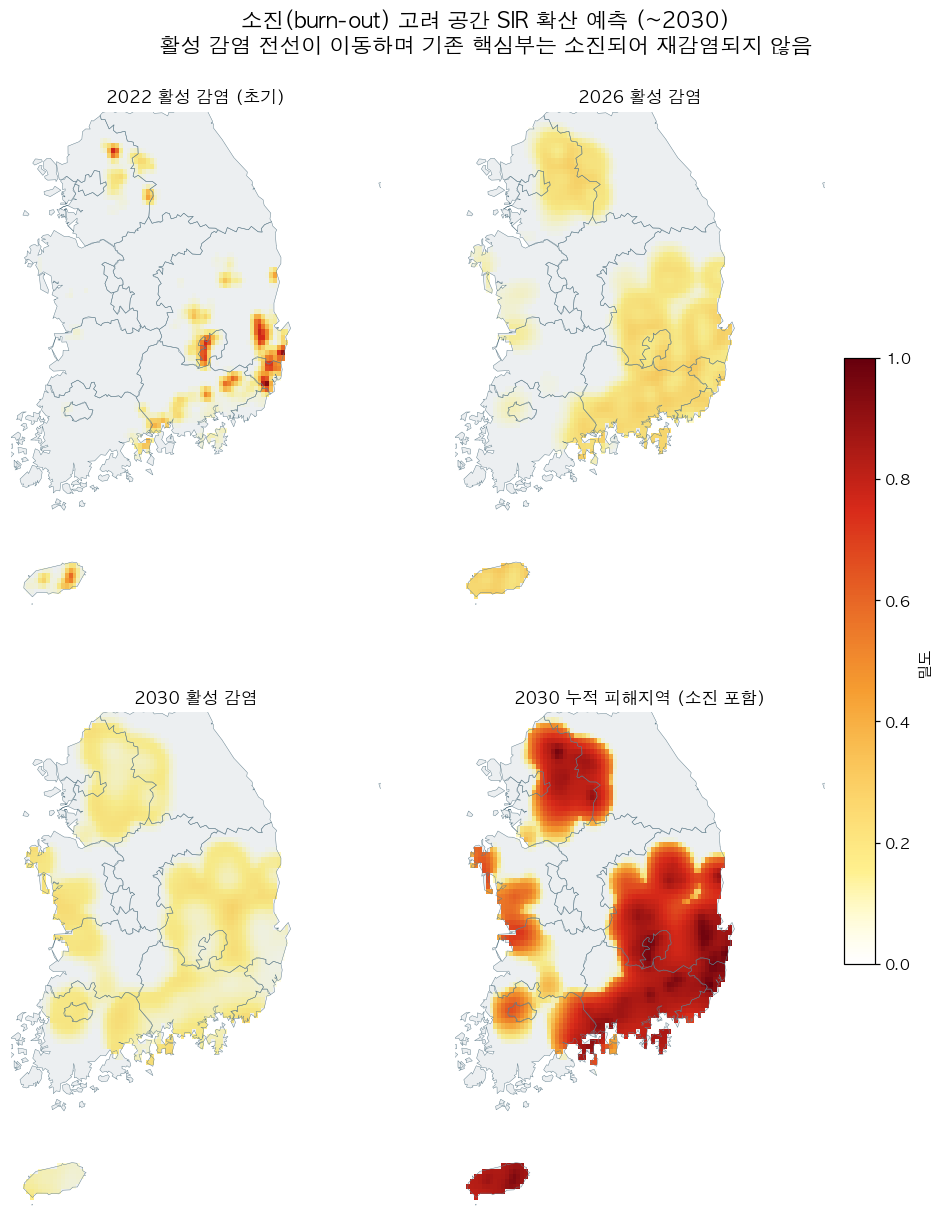

saved → 09_sir_forecast_2030.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 13))
plot_field(axes[0, 0], ex, ey, obs_density(2022), "2022 활성 감염 (초기)", shading="flat")
plot_field(axes[0, 1], ex, ey, sir_I[2026], "2026 활성 감염", shading="flat")
plot_field(axes[1, 0], ex, ey, sir_I[2030], "2030 활성 감염", shading="flat")
pcm = plot_field(axes[1, 1], ex, ey, sir_A[2030], "2030 누적 피해지역 (소진 포함)", shading="flat")
fig.colorbar(pcm, ax=axes, shrink=0.55, pad=0.02, label="밀도")
fig.suptitle("소진(burn-out) 고려 공간 SIR 확산 예측 (~2030)\n"
             "활성 감염 전선이 이동하며 기존 핵심부는 소진되어 재감염되지 않음", fontsize=14, y=0.95)
fig.savefig(f"{OUT}/09_sir_forecast_2030.png", dpi=135, bbox_inches="tight")
plt.show(); print("saved → 09_sir_forecast_2030.png")

## 9. 추가 분석 — 시도별 피해 순위 · 피해 추이

- **시도별 피해 순위**: 예측 격자 셀을 17개 시도에 공간 배정해 시도별 감염밀도 합(상대 피해지수)을 집계.
- **피해 추이 곡선**: 관측(2016–2023) → PINN 예측(2024–2026) → 소진 고려 SIR(~2030, 활성·누적)을 전국 평균으로 한 장에 요약.

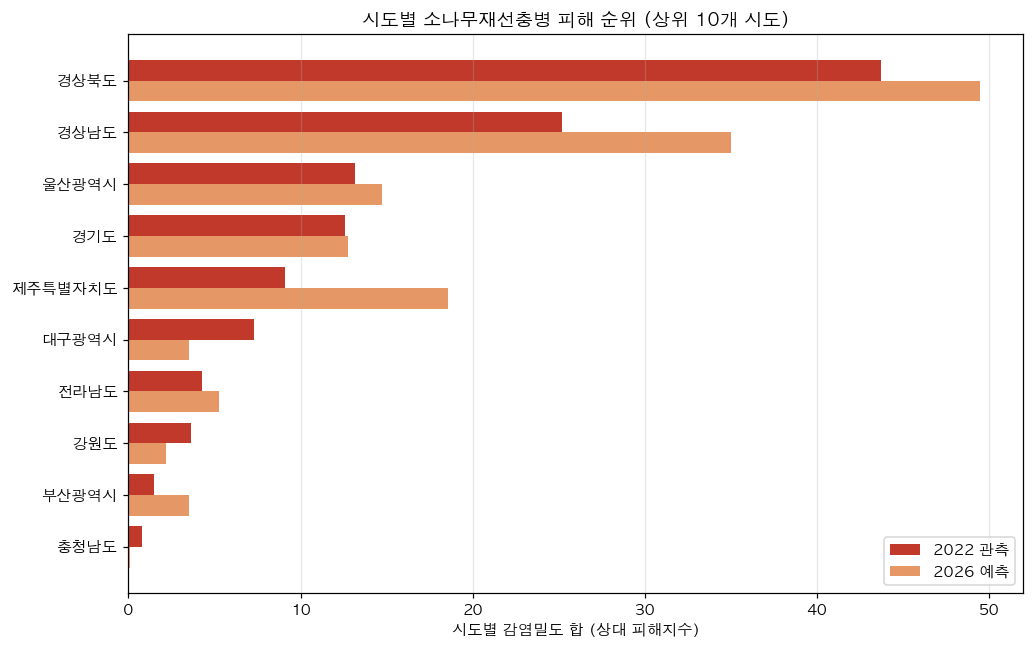

피해 상위 5개 시도(2022): 경상북도(44), 경상남도(25), 울산광역시(13), 경기도(13), 제주특별자치도(9)
saved → 10_province_damage.png


In [17]:
# ── 시도별 격자 배정 (96격자 육지셀 → 시도) ──
coarse_pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(CX.ravel()[land_idx], CY.ravel()[land_idx]), crs=SRC_CRS)
PROV = gpd.sjoin(coarse_pts, KOREA[["name", "geometry"]], how="left", predicate="within")["name"].to_numpy()

def prov_sum(values):                                  # land_idx 순서의 값 → 시도별 합
    return pd.Series(values, index=PROV).groupby(level=0).sum()

obs22  = prov_sum(U_OBS[YEARS_TRAIN.index(2022)].ravel()[land_idx])   # 2022 관측
pred26 = prov_sum(model_on_coarse(2026))                              # 2026 예측
top = obs22.sort_values(ascending=False).head(10).index

fig, ax = plt.subplots(figsize=(9.5, 6))
yy = np.arange(len(top))
ax.barh(yy - 0.2, obs22[top].values,                 height=0.4, color="#c0392b", label="2022 관측")
ax.barh(yy + 0.2, pred26.reindex(top).fillna(0).values, height=0.4, color="#e59866", label="2026 예측")
ax.set_yticks(yy); ax.set_yticklabels(top); ax.invert_yaxis()
ax.set_xlabel("시도별 감염밀도 합 (상대 피해지수)"); ax.legend()
ax.set_title("시도별 소나무재선충병 피해 순위 (상위 10개 시도)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(); fig.savefig(f"{OUT}/10_province_damage.png", dpi=140, bbox_inches="tight")
plt.show()
print("피해 상위 5개 시도(2022):", ", ".join(f"{p}({obs22[p]:.0f})" for p in top[:5]))
print("saved → 10_province_damage.png")

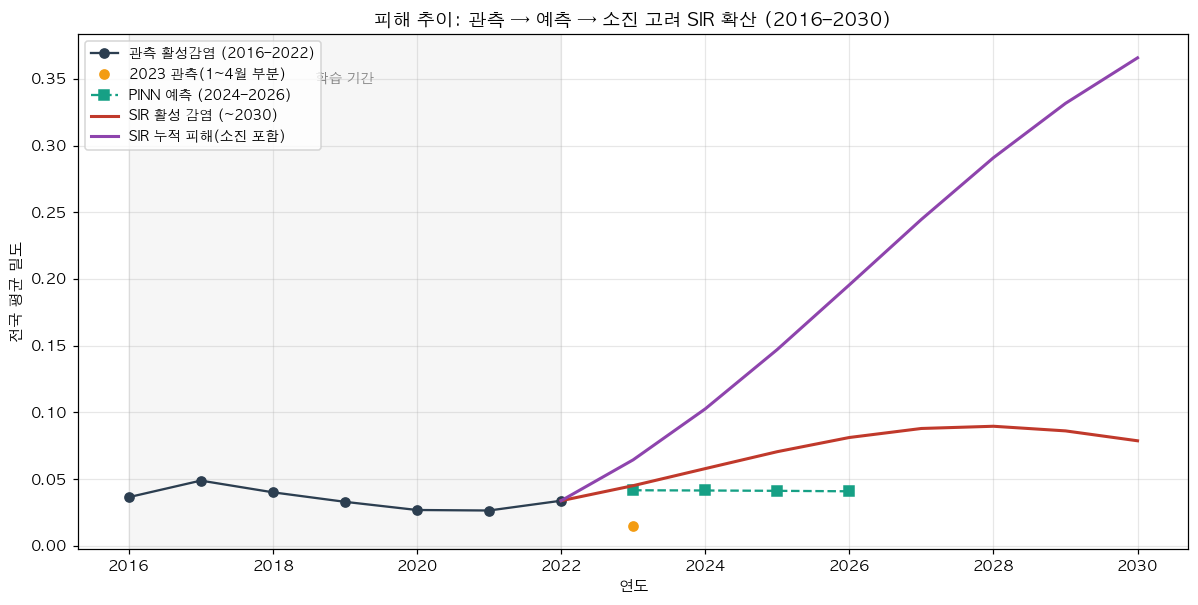

saved → 11_damage_trajectory.png


In [18]:
# ── 피해 추이: 관측 → PINN 예측 → 소진 고려 SIR (2016–2030) ──
mlc = lambda u96: float(np.nanmean(np.where(LAND, u96, np.nan)))
obs_years = list(range(2016, 2024))
obs_vals  = [mlc(obs_density(y)) for y in obs_years]
pinn_years = [2023, 2024, 2025, 2026]
pinn_vals  = [float(model_on_coarse(y).mean()) for y in pinn_years]
sir_years = list(range(2022, 2031))
sirI_vals = [mlc(sir_I[y]) for y in sir_years]
sirA_vals = [mlc(sir_A[y]) for y in sir_years]

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.axvspan(2016, 2022, color="gray", alpha=0.07)
ax.text(2019, max(sirA_vals) * 0.95, "학습 기간", ha="center", fontsize=9, color="gray")
ax.plot(obs_years[:-1], obs_vals[:-1], "o-", color="#2c3e50", label="관측 활성감염 (2016–2022)")
ax.plot([2023], [obs_vals[-1]], "o", color="#f39c12", label="2023 관측(1~4월 부분)")
ax.plot(pinn_years, pinn_vals, "s--", color="#16a085", label="PINN 예측 (2024–2026)")
ax.plot(sir_years, sirI_vals, "-", color="#c0392b", lw=2, label="SIR 활성 감염 (~2030)")
ax.plot(sir_years, sirA_vals, "-", color="#8e44ad", lw=2, label="SIR 누적 피해(소진 포함)")
ax.set_xlabel("연도"); ax.set_ylabel("전국 평균 밀도")
ax.set_title("피해 추이: 관측 → 예측 → 소진 고려 SIR 확산 (2016–2030)")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(f"{OUT}/11_damage_trajectory.png", dpi=140, bbox_inches="tight")
plt.show(); print("saved → 11_damage_trajectory.png")

## 10. 요약

In [19]:
print("=" * 62)
print(" ✅ 완료 — Fisher-KPP PINN 소나무재선충병 피해 예측 (2016–2023 데이터)")
print("=" * 62)
print(f" 감염목 데이터        : {len(PX):,} 건 (2016–2023, 2023은 1~4월 부분)")
print(f" 학습 스냅샷          : {YEARS_TRAIN}")
print(f" 검증 연도            : {YEAR_VALID} (부분관측, 공간상관 r={CORR23:.2f})")
print(f" 예측 연도            : {YEARS_FCST}")
print(f" 소진 고려 SIR 예측    : ~2030 (β={BETA}, γ={GAMMA}, R0≈{BETA/GAMMA:.0f}; 감염→제거 후 재감염 없음)")
print(f" 학습된 확산계수 D    : {D_phys:.1f} km²/년")
print(f" 학습된 성장률   r    : {r_phys:.3f} /년")
print(f" 확산 전파속도(근사)  : {speed:.1f} km/년")
print("\n 저장된 결과 이미지:")
for p in sorted(glob.glob(f"{OUT}/*.png")):
    print("   -", p)
print("\n ※ 2016년 이후 감염목 총량은 정점(2017) 후 감소 추세(방제 효과). 절대수치보다 공간 추세 해석 권장.")

 ✅ 완료 — Fisher-KPP PINN 소나무재선충병 피해 예측 (2016–2023 데이터)
 감염목 데이터        : 3,183,376 건 (2016–2023, 2023은 1~4월 부분)
 학습 스냅샷          : [2016, 2017, 2018, 2019, 2020, 2021, 2022]
 검증 연도            : 2023 (부분관측, 공간상관 r=0.47)
 예측 연도            : [2024, 2025, 2026]
 소진 고려 SIR 예측    : ~2030 (β=1.2, γ=0.5, R0≈2; 감염→제거 후 재감염 없음)
 학습된 확산계수 D    : 15.5 km²/년
 학습된 성장률   r    : 0.005 /년
 확산 전파속도(근사)  : 0.6 km/년

 저장된 결과 이미지:
   - outputs/01_eda_overview.png
   - outputs/02_observed_density_by_year.png
   - outputs/03_training_loss.png
   - outputs/04_pinn_fit_vs_observed.png
   - outputs/05_validation_2023.png
   - outputs/06_forecast_future.png
   - outputs/07_spread_timeline.png
   - outputs/08_hotspot_change.png
   - outputs/09_sir_forecast_2030.png
   - outputs/10_province_damage.png
   - outputs/11_damage_trajectory.png

 ※ 2016년 이후 감염목 총량은 정점(2017) 후 감소 추세(방제 효과). 절대수치보다 공간 추세 해석 권장.
